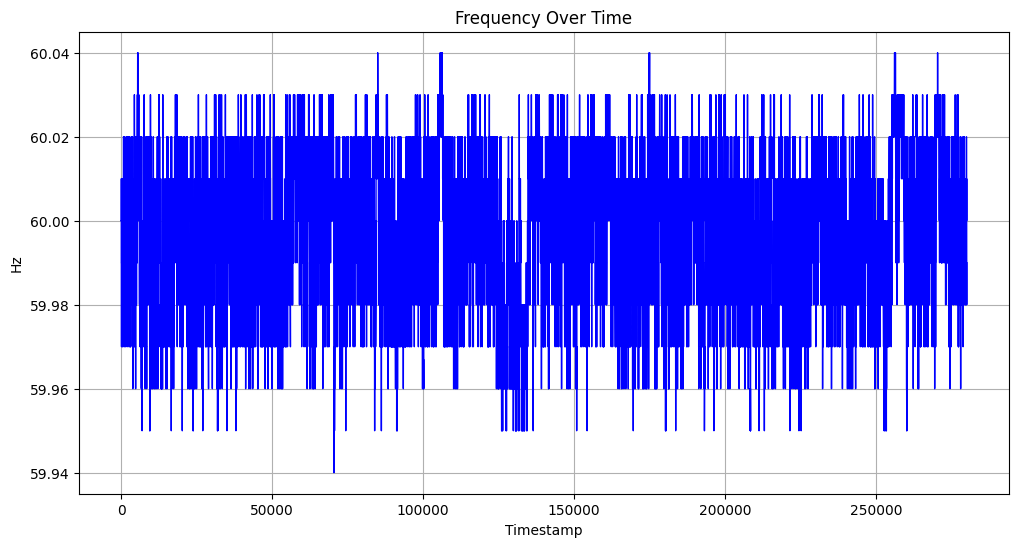

Scaled shape: (280091, 1)
Scaled shape: (280091, 1)


In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

DATA_PATH = os.path.join('..', 'src', 'Train_data', 'V_0_processed_active.csv')

df = pd.read_csv(DATA_PATH)  

# 3. Plot the raw Hz values
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Hz'], color='blue', linewidth=1)
plt.title('Frequency Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Hz')
plt.grid(True)
plt.show()

# 4. Scale the Hz values using MinMaxScaler
scaler = MinMaxScaler()
hz_values = df[['Hz']].values
hz_scaled = scaler.fit_transform(hz_values)

print("Scaled shape:", hz_scaled.shape)


scaler = MinMaxScaler()

hz_values = df[['Hz']].values
hz_scaled = scaler.fit_transform(hz_values)

print("Scaled shape:", hz_scaled.shape)


In [ ]:
# ============================================================================
# STEP 1: Install Optuna (Run this first in a separate cell)
# ============================================================================
# !pip install optuna

# ============================================================================
# STEP 2: Import Additional Libraries
# ============================================================================
import numpy as np
import pandas as pd
import random
import seaborn as sns
from matplotlib import pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, RepeatVector, TimeDistributed, Dense
from sklearn.preprocessing import MinMaxScaler
import optuna
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# STEP 3: Define the Objective Function for Optuna
# ============================================================================

def create_sequences(data, seq_size):
    """Create sequences for time series"""
    X = []
    for i in range(len(data) - seq_size):
        X.append(data[i:i + seq_size])
    return np.array(X)

def objective(trial):
    """
    Objective function that Optuna will optimize.
    Tests different hyperparameter combinations and returns validation loss.
    """
    
    # ========== Suggest Hyperparameters ==========
    seq_size = trial.suggest_categorical('seq_size', [20, 30, 40, 50])
    lstm1_units = trial.suggest_categorical('lstm1_units', [64, 128, 256])
    lstm2_units = trial.suggest_categorical('lstm2_units', [32, 64, 128])
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.4)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    learning_rate = trial.suggest_loguniform('learning_rate', 1e-4, 1e-2)
    epochs = trial.suggest_int('epochs', 20, 50, step=10)
    
    # ========== Create Sequences with Current seq_size ==========
    X_temp = create_sequences(hz_scaled, seq_size)
    y_temp = X_temp.copy()
    
    # ========== Build Model ==========
    input_shape = (seq_size, X_temp.shape[2])
    
    model = Sequential()
    
    model.add(LSTM(
        lstm1_units,
        activation='tanh',
        recurrent_activation='sigmoid',
        input_shape=input_shape,
        return_sequences=True
    ))
    model.add(Dropout(dropout_rate))
    
    model.add(LSTM(
        lstm2_units,
        activation='tanh',
        recurrent_activation='sigmoid',
        return_sequences=False
    ))
    model.add(Dropout(dropout_rate))
    
    model.add(RepeatVector(input_shape[0]))
    
    model.add(LSTM(
        lstm2_units,
        activation='tanh',
        recurrent_activation='sigmoid',
        return_sequences=True
    ))
    model.add(Dropout(dropout_rate))
    
    model.add(LSTM(
        lstm1_units,
        activation='tanh',
        recurrent_activation='sigmoid',
        return_sequences=True
    ))
    model.add(Dropout(dropout_rate))
    
    model.add(TimeDistributed(Dense(input_shape[1])))
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mae',
        metrics=['mape']
    )
    
    # ========== Train Model ==========
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=0
    )
    
    history = model.fit(
        X_temp, y_temp,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0  # Silent training
    )
    
    # ========== Return Best Validation Loss ==========
    best_val_loss = min(history.history['val_loss'])
    
    # Clean up to free memory
    del model
    tf.keras.backend.clear_session()
    
    return best_val_loss

# ============================================================================
# STEP 4: Run Optuna Optimization
# ============================================================================

print("="*80)
print("STARTING OPTUNA HYPERPARAMETER OPTIMIZATION")
print("="*80)
print(f"Dataset shape: {hz_scaled.shape}")
print(f"This will test different combinations of hyperparameters to find the best.")
print(f"Estimated time: 2-4 hours for 50 trials")
print("="*80)

# Create Optuna study
study = optuna.create_study(
    direction='minimize',  # We want to minimize validation loss
    study_name='lstm_autoencoder_optimization'
)

# Run optimization
study.optimize(
    objective,
    n_trials=50,  # Number of different configurations to try
    show_progress_bar=True,
    n_jobs=1  # Use 1 for GPU, increase for CPU parallelization
)

# ============================================================================
# STEP 5: Display Results
# ============================================================================

print("\n" + "="*80)
print("OPTIMIZATION COMPLETE!")
print("="*80)

print(f"\nBest Validation Loss: {study.best_value:.6f}")

print("\n" + "="*80)
print("BEST HYPERPARAMETERS:")
print("="*80)
for key, value in study.best_params.items():
    print(f"{key:20s}: {value}")
print("="*80)

# ============================================================================
# STEP 6: Save Results
# ============================================================================

# Save all trials to CSV
results_df = study.trials_dataframe()
results_df.to_csv('optuna_optimization_results.csv', index=False)
print(f"\n✅ All trials saved to: optuna_optimization_results.csv")

# Save best parameters to JSON
import json
with open('best_hyperparameters.json', 'w') as f:
    json.dump(study.best_params, f, indent=4)
print(f"✅ Best parameters saved to: best_hyperparameters.json")

# ============================================================================
# STEP 7: Visualize Optimization Process (MATPLOTLIB VERSION)
# ============================================================================

print("\n" + "="*80)
print("CREATING OPTIMIZATION VISUALIZATIONS")
print("="*80)

# Create a figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ========== Plot 1: Optimization History ==========
ax1 = axes[0]

# Get trial numbers and values
trial_numbers = [trial.number for trial in study.trials]
trial_values = [trial.value if trial.value is not None else float('nan') for trial in study.trials]

# Plot all trials
ax1.scatter(trial_numbers, trial_values, alpha=0.5, s=50, label='Trial')

# Plot best value line
best_values = []
current_best = float('inf')
for val in trial_values:
    if val is not None and not np.isnan(val):
        current_best = min(current_best, val)
    best_values.append(current_best if current_best != float('inf') else None)

ax1.plot(trial_numbers, best_values, 'r-', linewidth=2, label='Best Value')

ax1.set_xlabel('Trial Number', fontsize=12)
ax1.set_ylabel('Validation Loss (MAE)', fontsize=12)
ax1.set_title('Optimization History', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# ========== Plot 2: Parameter Importances ==========
ax2 = axes[1]

# Calculate parameter importances
try:
    importances = optuna.importance.get_param_importances(study)
    
    # Sort by importance
    params = list(importances.keys())
    values = list(importances.values())
    
    # Create horizontal bar chart
    y_pos = np.arange(len(params))
    ax2.barh(y_pos, values, alpha=0.7, color='steelblue')
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(params)
    ax2.set_xlabel('Importance', fontsize=12)
    ax2.set_title('Hyperparameter Importances', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='x')
    
except Exception as e:
    ax2.text(0.5, 0.5, f'Parameter importance calculation\nnot available:\n{str(e)}', 
             ha='center', va='center', transform=ax2.transAxes)
    ax2.set_title('Hyperparameter Importances', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('optuna_optimization_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Optimization visualizations saved to: optuna_optimization_analysis.png")

# ============================================================================
# STEP 8: Additional Visualization - Parameter Distributions
# ============================================================================

# Get all trials data
trials_df = study.trials_dataframe()

# Create figure for parameter distributions
param_names = list(study.best_params.keys())
n_params = len(param_names)
n_cols = 3
n_rows = (n_params + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten() if n_params > 1 else [axes]

for idx, param_name in enumerate(param_names):
    ax = axes[idx]
    col_name = f'params_{param_name}'
    
    if col_name in trials_df.columns:
        param_values = trials_df[col_name].dropna()
        objective_values = trials_df.loc[param_values.index, 'value']
        
        # Scatter plot of parameter vs objective
        scatter = ax.scatter(param_values, objective_values, 
                           c=objective_values, cmap='viridis', 
                           alpha=0.6, s=50)
        
        # Mark best trial
        best_trial_idx = trials_df['value'].idxmin()
        if best_trial_idx in param_values.index:
            best_param_val = trials_df.loc[best_trial_idx, col_name]
            best_obj_val = trials_df.loc[best_trial_idx, 'value']
            ax.scatter([best_param_val], [best_obj_val], 
                      color='red', s=200, marker='*', 
                      edgecolors='black', linewidths=2,
                      label='Best Trial', zorder=5)
        
        ax.set_xlabel(param_name, fontsize=10)
        ax.set_ylabel('Validation Loss', fontsize=10)
        ax.set_title(f'{param_name} vs Objective', fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        if idx == 0:
            ax.legend()
        
        plt.colorbar(scatter, ax=ax, label='Val Loss')

# Hide unused subplots
for idx in range(n_params, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('optuna_parameter_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Parameter distributions saved to: optuna_parameter_distributions.png")

# ============================================================================
# STEP 9: Train Final Model with Best Parameters
# ============================================================================

print("\n" + "="*80)
print("TRAINING FINAL MODEL WITH BEST HYPERPARAMETERS")
print("="*80)

best_params = study.best_params

# Create sequences with best seq_size
X_final = create_sequences(hz_scaled, best_params['seq_size'])
y_final = X_final.copy()

# Build final model
input_shape_final = (best_params['seq_size'], X_final.shape[2])

final_model = Sequential()

final_model.add(LSTM(
    best_params['lstm1_units'],
    activation='tanh',
    recurrent_activation='sigmoid',
    input_shape=input_shape_final,
    return_sequences=True
))
final_model.add(Dropout(best_params['dropout_rate']))

final_model.add(LSTM(
    best_params['lstm2_units'],
    activation='tanh',
    recurrent_activation='sigmoid',
    return_sequences=False
))
final_model.add(Dropout(best_params['dropout_rate']))

final_model.add(RepeatVector(input_shape_final[0]))

final_model.add(LSTM(
    best_params['lstm2_units'],
    activation='tanh',
    recurrent_activation='sigmoid',
    return_sequences=True
))
final_model.add(Dropout(best_params['dropout_rate']))

final_model.add(LSTM(
    best_params['lstm1_units'],
    activation='tanh',
    recurrent_activation='sigmoid',
    return_sequences=True
))
final_model.add(Dropout(best_params['dropout_rate']))

final_model.add(TimeDistributed(Dense(input_shape_final[1])))

final_model.compile(
    optimizer=Adam(learning_rate=best_params['learning_rate']),
    loss='mae',
    metrics=['mape']
)

print("\nFinal Model Summary:")
final_model.summary()

# Train final model
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

final_history = final_model.fit(
    X_final, y_final,
    epochs=best_params['epochs'],
    batch_size=best_params['batch_size'],
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Save final model
final_model.save('best_lstm_autoencoder.h5')
print("\n✅ Final model saved to: best_lstm_autoencoder.h5")

# ============================================================================
# STEP 10: Plot Final Training Results
# ============================================================================

plt.figure(figsize=(14, 5))

# Plot 1: Loss
plt.subplot(1, 2, 1)
plt.plot(final_history.history['loss'], label='Train MAE')
plt.plot(final_history.history['val_loss'], label='Val MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Final Model: Training Loss (Best Hyperparameters)')
plt.legend()
plt.grid(True)

# Plot 2: MAPE
plt.subplot(1, 2, 2)
plt.plot(final_history.history['mape'], label='Train MAPE')
plt.plot(final_history.history['val_mape'], label='Val MAPE')
plt.xlabel('Epoch')
plt.ylabel('MAPE')
plt.title('Final Model: Training MAPE (Best Hyperparameters)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('final_model_training.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# STEP 11: Compare with Original Model
# ============================================================================

print("\n" + "="*80)
print("COMPARISON: ORIGINAL vs OPTIMIZED MODEL")
print("="*80)

# Original configuration (from your notebook)
original_config = {
    'seq_size': 30,
    'lstm1_units': 256,
    'lstm2_units': 128,
    'dropout_rate': 0.1458640824745126,
    'batch_size': 128,
    'learning_rate': 0.0021166148685259267,
    'epochs': 40
}

print("\nOriginal Configuration:")
for key, value in original_config.items():
    print(f"  {key:20s}: {value}")

print("\nOptimized Configuration:")
for key, value in best_params.items():
    print(f"  {key:20s}: {value}")

print("\n" + "="*80)
print("✅ OPTIMIZATION COMPLETE!")
print(f"Best Validation Loss: {study.best_value:.6f}")
print("="*80)

c:\Users\muhammad.karim\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-01-29 11:22:41,172] A new study created in memory with name: lstm_autoencoder_optimization


STARTING OPTUNA HYPERPARAMETER OPTIMIZATION
Dataset shape: (280091, 1)
This will test different combinations of hyperparameters to find the best.
Estimated time: 2-4 hours for 50 trials


  0%|          | 0/50 [03:24<?, ?it/s]


[W 2026-01-29 11:26:05,511] Trial 0 failed with parameters: {'seq_size': 30, 'lstm1_units': 128, 'lstm2_units': 64, 'dropout_rate': 0.28526719894815505, 'batch_size': 128, 'learning_rate': 0.00045738398798405677, 'epochs': 40} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\muhammad.karim\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\muhammad.karim\AppData\Local\Temp\ipykernel_3020\532603840.py", line 109, in objective
    history = model.fit(
              ^^^^^^^^^^
  File "c:\Users\muhammad.karim\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\utils\traceback_utils.py", line 117, in error_handler
    return fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "c:\Users\muhammad.karim\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\backe

KeyboardInterrupt: 